In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import yfinance as yf
df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
df = df[['Close']]
df.head()

ModuleNotFoundError: No module named 'yfinance'

In [3]:
!pip install yfinance

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import yfinance as yf
df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
df = df[['Close']]
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2020-01-02,72.333862
2020-01-03,71.630623
2020-01-06,72.201416
2020-01-07,71.861855
2020-01-08,73.017830


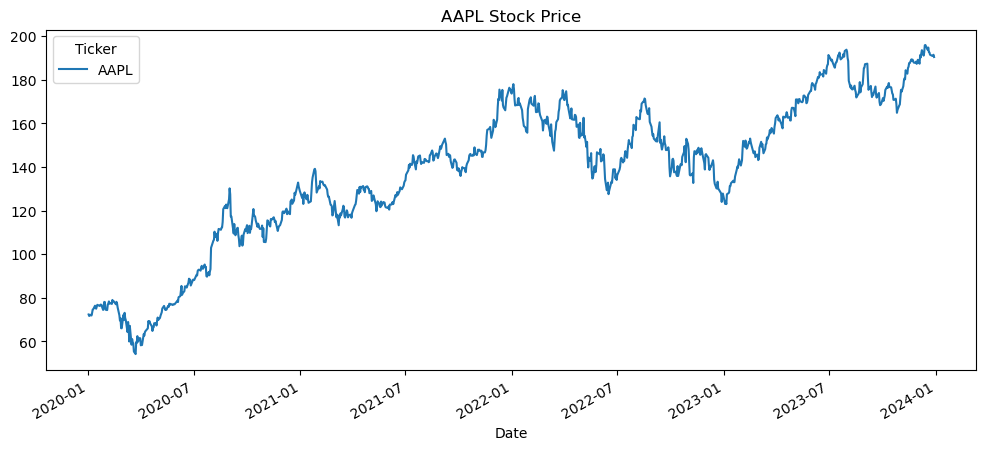

In [5]:
df['Close'].plot(figsize=(12,5), title='AAPL Stock Price')
plt.show()

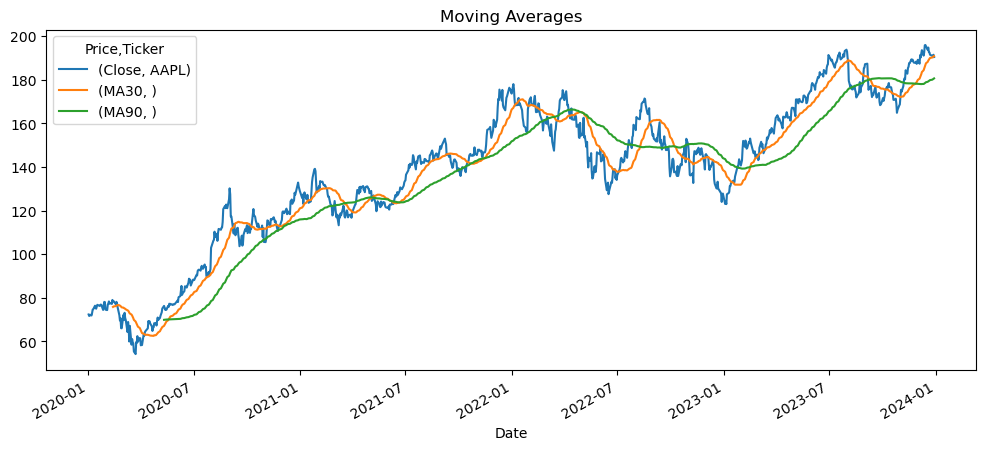

In [6]:
df['MA30'] = df['Close'].rolling(window=30).mean()
df['MA90'] = df['Close'].rolling(window=90).mean()

df[['Close', 'MA30', 'MA90']].plot(figsize=(12,5), title='Moving Averages')
plt.show()

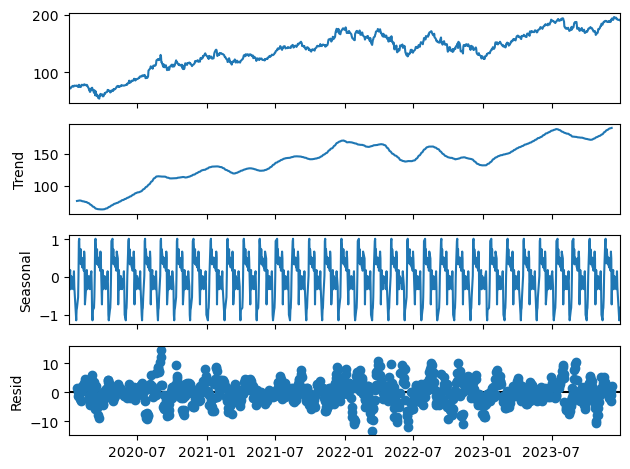

In [7]:
result = seasonal_decompose(df['Close'], model='additive', period=30)
result.plot()
plt.show()

In [8]:
adf_result = adfuller(df['Close'].dropna())
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")

ADF Statistic: -1.5119516589413462
p-value: 0.527590957199104
Data is Non-Stationary
